# Notebook 3 — FakeHealth · BioBERT Classifier & Benchmark
## BioBERT embeddings → Classifieurs ML · Benchmark vs TF-IDF Baselines

**Projet :** A Multi-Source Benchmark for CVD Health Misinformation Detection  
**Dataset :** FakeHealth HealthStory — Dai, Sun & Wang (ICWSM 2020)  
**Modèle :** `dmis-lab/biobert-base-cased-v1.2` (HuggingFace)  
**Prérequis :** Avoir exécuté NB1 (génère `healthstory_baseline_ready.csv`) et NB2 (résultats TF-IDF)

---
### What does this notebook do?
1. Load `HealthStory_clean.csv`
2. Tokenize texts with **BioBERT tokenizer**
3. Extract **CLS-token embeddings** (and optionally mean-pooling) from BioBERT
4. Train classifiers **on top of BioBERT embeddings** : Logistic Regression, LinearSVC, MLP
5. 5-fold stratified cross-validation (same protocol as NB2)
6. Final evaluation on held-out test set (same 80/20 split as NB2)
7. **Benchmark TABLE 1** : TF-IDF baselines (NB2) vs BioBERT classifiers
8. Error analysis + confusion matrices
9. PCA visualization of the BioBERT embedding space

In [1]:
# import librairies
import pandas as pd 
import numpy as np 
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mticker
import glob
import re
import json
import unicodedata
from pathlib import Path

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Imports OK')
print(f'   torch   {torch.__version__}')
print(f'   device  {DEVICE}')



 Imports OK
   torch   2.10.0+cu128
   device  cpu


# Loading data 

In [2]:
candidate_path = ['../dataset/healthstory_baseline_ready.csv',
    'HealthStory_clean.csv']
CSV_PATH = next( (p for p in candidate_path if os.path.exists(p)), None)
if (CSV_PATH is None) :
    raise FileNotFoundError ('File not found in candidate path\n')
df = pd.read_csv(CSV_PATH, encoding='utf-8')
print(f'All data loaded: {len(df)} articles')
print(f'CSV used: {CSV_PATH}')

All data loaded: 1638 articles
CSV used: ../dataset/healthstory_baseline_ready.csv


In [3]:
# VCheck and execute
print('── Raised values ──')
print(df.isnull().sum().to_string())
print()

# Remove all lines without body and title
n_before = len(df)
df = df.dropna(subset=['label'])

# Colone texte : combine title + body
has_body  = 'body'  in df.columns
has_title = 'title' in df.columns

if has_body and has_title:
    df['text'] = df['title'].fillna('') + ' ' + df['body'].fillna('')
    print(' Colone text = has title + body')
elif has_body:
    df['text'] = df['body'].fillna('')
    print(' Colonne text = has only body')
elif has_title:
    df['text'] = df['title'].fillna('')
    print('Colonne text = has title only  (missing body )')
else:
    raise ValueError('No "body" no "title" find in this path.')

df = df[df['text'].str.strip().astype(bool)]  

print(f'   Articles conserved : {len(df)} (removed : {n_before - len(df)})')

X = df['text'].values
y = df['label'].values

print(f'   Fake (0) : {(y==0).sum()} | Real (1) : {(y==1).sum()}')

── Raised values ──
file_id          0
title           34
text            24
label            0
label_name       0
rating_float     0
dataset          0

Colonne text = has title only  (missing body )
   Articles conserved : 1604 (removed : 34)
   Fake (0) : 450 | Real (1) : 1154



# Section 3 — BioBERT Model Loading

We use `dmis-lab/biobert-base-cased-v1.2` from HuggingFace.  
This is the canonical BioBERT model pre-trained on PubMed + PMC biomedical texts.

| Parameter | Value |
|---|---|
| Model | `dmis-lab/biobert-base-cased-v1.2` |
| Max tokens | 512 (BERT limit) |
| Truncation | Tail truncation (keep first 512 tokens) |
| Embedding | CLS token (index 0 of last hidden state) |
| Batch size | 16 (adjust down if OOM) |

In [4]:
# ── BioBERT model loading
# We load the BioBERT tokenizer and model from HuggingFace, then move the model to the chosen device.
# The model is set to evaluation mode because we only need forward passes to extract embeddings.
BIOBERT_MODEL = 'dmis-lab/biobert-base-cased-v1.2'
tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL)
biobert = AutoModel.from_pretrained(BIOBERT_MODEL)
biobert = biobert.to(DEVICE)
biobert.eval()

print(f' BioBERT loaded: {BIOBERT_MODEL}')
print(f'   Parameters : {sum(p.numel() for p in biobert.parameters()):,}')
print(f'   Hidden size: {biobert.config.hidden_size}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 BioBERT loaded: dmis-lab/biobert-base-cased-v1.2
   Parameters : 108,310,272
   Hidden size: 768


## Section 4 — BioBERT Embedding Extraction

For each article, we:
1. Tokenize with BioBERT tokenizer (max 512 tokens, truncate tail)
2. Run a forward pass (no gradient)
3. Extract the **CLS token** (first token) from the last hidden state → 768-dim vector

This produces a fixed-size semantic representation of each article.


In [5]:
def extract_biobert_embeddings(texts, tokenizer, model, device, batch_size=16, max_length=512, pooling='cls'):
    """
    Extract fixed-size embeddings from a list of texts using BioBERT.

    Args:
        texts      : list/array of raw strings to encode.
        tokenizer  : HuggingFace tokenizer for BioBERT.
        model      : HuggingFace model already moved to the target device.
        device     : torch.device where tensors are allocated.
        batch_size : number of texts processed in one forward pass.
        max_length : maximum number of tokens per text (512 for BERT).
        pooling    : 'cls' to use the CLS token vector, 'mean' to average token vectors.

    Returns:
        np.ndarray of shape (n_texts, hidden_size) containing one embedding per text.
    """
    all_embeddings = []
    n = len(texts)

    # Print a short summary before starting the extraction loop.
    print(f'Extracting {pooling} - pooled BioBERT embeddings ...')
    print(f'   {n} texts | batch_size={batch_size} | max_length={max_length}')
    print(f'   device = {device}')

    # Process the texts in batches to avoid out-of-memory errors.
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch = list(texts[start:end])

        # Tokenize the current batch.
        # padding=True pads all sequences in the batch to the same length.
        # truncation=True cuts sequences longer than max_length.
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )

        # Move token tensors to the model device (CPU or GPU).
        encoded = {k: v.to(device) for k, v in encoded.items()}

        # Disable gradient computation for inference to save memory and time.
        with torch.no_grad():
            outputs = model(**encoded)

        # last_hidden_state has shape (batch_size, sequence_length, hidden_size).
        last_hidden = outputs.last_hidden_state

        if pooling == 'cls':
            # Use the CLS token embedding from the first position.
            embeddings = last_hidden[:, 0, :]
        elif pooling == 'mean':
            # Use mean pooling over the token vectors, masking padded tokens.
            mask = encoded['attention_mask'].unsqueeze(-1).float()
            embeddings = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1)
        else:
            raise ValueError(f'Unknown pooling: {pooling}')

        # Convert the batch embeddings to NumPy and store them.
        all_embeddings.append(embeddings.cpu().numpy())

        # Progress indicator for every 10 batches.
        if (start // batch_size) % 10 == 0:
            print(f'   [{end}/{n}] done', end='\r')

    # End of all batches.
    print(f'   [{n}/{n}] done        ')

    # Stack all batch embeddings into a single array of shape (n, hidden_size).
    result = np.vstack(all_embeddings)
    print(f' Embedding matrix shape: {result.shape}')
    return result

In [6]:
# embedding cache : avoid re-extracting embeddings every time we run the notebook
EMBEDDING_CACHE_PATH = 'biobert_embeddings.npy'
if os.path.exists(EMBEDDING_CACHE_PATH):
    print(f'Loading cached embeddings from {EMBEDDING_CACHE_PATH} ...')
    X_embeddings = np.load(EMBEDDING_CACHE_PATH)
    print(f' Embeddings loaded: {X_embeddings.shape}')
else:
    print('No cached embeddings found, extracting from BioBERT this may take time...')
    X_embeddings = extract_biobert_embeddings(
        texts=X,
        tokenizer=tokenizer,
        model=biobert,
        device=DEVICE,
        batch_size=16,
        max_length=512,
        pooling='cls'
    )
    np.save(EMBEDDING_CACHE_PATH, X_embeddings)
    print(f'Embeddings saved to cache: {EMBEDDING_CACHE_PATH}') 

print('All steps completed successfully.')
    

Loading cached embeddings from biobert_embeddings.npy ...
 Embeddings loaded: (1604, 768)
All steps completed successfully.


In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import torch

queries = [
    "cardiovascular disease", "cardiovascular disorders", "heart disease", "cardiac disease", "coronary artery disease", "coronary heart disease", "ischemic heart disease", "myocardial ischemia", "myocardial infarction", "heart attack", "acute coronary syndrome", "stroke", "ischemic stroke", "hemorrhagic stroke", "cerebrovascular accident", "transient ischemic attack", "tia", "hypertension", "high blood pressure", "arterial hypertension", "heart failure", "congestive heart failure", "arrhythmia", "atrial fibrillation", "ventricular arrhythmia",
    "chest pain", "angina", "stable angina", "unstable angina", "shortness of breath", "dyspnea", "exertional dyspnea", "palpitations", "tachycardia", "bradycardia", "fatigue", "chronic fatigue", "exercise intolerance", "dizziness", "vertigo", "lightheadedness", "syncope", "fainting", "loss of consciousness", "edema", "peripheral edema", "swelling",
    "smoking", "tobacco use", "nicotine exposure", "obesity", "overweight", "bmi", "body mass index", "high cholesterol", "hyperlipidemia", "ldl", "hdl", "triglycerides", "diabetes", "insulin resistance", "sedentary lifestyle", "physical inactivity", "family history", "genetic predisposition", "age", "male sex", "stress", "poor diet",
    "statins", "beta-blockers", "ace inhibitors", "arbs", "antihypertensive drugs", "anticoagulants", "blood thinners", "aspirin therapy", "antiplatelet therapy", "angioplasty", "percutaneous coronary intervention", "stent", "coronary stent", "bypass surgery", "coronary artery bypass graft", "cardiac rehabilitation",
    "ecg", "electrocardiogram", "ekg", "blood pressure", "ambulatory blood pressure monitoring", "cholesterol levels", "lipid panel", "troponin", "cardiac biomarkers", "echocardiogram", "cardiac ultrasound", "stress test", "exercise tolerance test", "ct angiography",
    "type 1 diabetes", "type 2 diabetes", "gestational diabetes", "prediabetes", "latent autoimmune diabetes", "lada", "mody", "maturity onset diabetes of the young",
    "frequent urination", "polyuria", "excessive thirst", "polydipsia", "polyphagia", "increased appetite", "weight loss", "unexplained weight loss", "blurred vision", "slow wound healing", "fatigue", "lethargy",
    "insulin", "insulin therapy", "metformin", "oral hypoglycemics", "glucose-lowering drugs", "sulfonylureas", "glp-1 agonists", "sglt2 inhibitors", "lifestyle intervention", "diet control", "carbohydrate counting", "continuous glucose monitoring", "cgm",
    "blood glucose", "blood sugar", "fasting glucose", "postprandial glucose", "hba1c", "glycated hemoglobin", "insulin level", "glucose tolerance test", "ogtt", "c-peptide",
    "neuropathy", "diabetic neuropathy", "nephropathy", "kidney disease", "retinopathy", "diabetic retinopathy", "diabetic foot ulcer", "cardiovascular complications", "macrovascular complications", "microvascular complications"
]

def embed_queries(queries, tokenizer, model, device):
    model.eval()
    enc = tokenizer(queries, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
    with torch.no_grad():
        return model(**enc).last_hidden_state[:, 0, :].cpu().numpy()


q_emb = embed_queries(queries, tokenizer, biobert, DEVICE)
df['topic_score'] = cosine_similarity(X_embeddings, q_emb).max(axis=1)


SEUIL_STRICT = 0.85

selected_df = df[df['topic_score'] >= SEUIL_STRICT].sort_values('topic_score', ascending=False).copy()

print(f'Selected {len(selected_df)} rows')
selected_df.head(10)

Selected 1533 rows


,file_id,title,text,label,label_name,rating_float,dataset,topic_score
164,story_reviews_01271,The Healthy Skeptic: telomerase activators,The Healthy Skeptic: telomerase activators,1,Real,3,HealthStory,0.935790
764,story_reviews_01658,Surgical procedure urged for atrial fibrillation,Surgical procedure urged for atrial fibrillation,1,Real,3,HealthStory,0.931148
1430,story_reviews_00808,Cervical cancer vaccine in early stages,Cervical cancer vaccine in early stages,1,Real,4,HealthStory,0.928114
886,story_reviews_01173,"Mediterranean diet cuts heart, diabetes risk f...","Mediterranean diet cuts heart, diabetes risk f...",1,Real,3,HealthStory,0.927866
393,story_reviews_01210,Breast-cancer study questions lymph node removal,Breast-cancer study questions lymph node removal,1,Real,4,HealthStory,0.927347
1012,story_reviews_00022,J&J's Stelara succeeds in chronic bowel diseas...,J&J's Stelara succeeds in chronic bowel diseas...,0,Fake,2,HealthStory,0.926088
1621,story_reviews_01596,Gene found that may predict lung cancer in smo...,Gene found that may predict lung cancer in smo...,1,Real,3,HealthStory,0.925159
1146,story_reviews_00012,Merck drug Keytruda succeeds in late-stage eso...,Merck drug Keytruda succeeds in late-stage eso...,0,Fake,1,HealthStory,0.924228
1208,story_reviews_00989,Medtronic tests stent for erectile dysfunction,Medtronic tests stent for erectile dysfunction,0,Fake,1,HealthStory,0.922992
1333,story_reviews_01516,Medtronic insulin pump beats injections in study,Medtronic insulin pump beats injections in study,0,Fake,1,HealthStory,0.922422


## Section 5 : Train / Split
80/20 stratified split.
`random_state=42`.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(' Split Train and  Test ')
print(f'  Train : {len(X_train)} articles  |  Fake: {(y_train==0).sum()}  Real: {(y_train==1).sum()}')
print(f'  Test  : {len(X_test)}  articles  |  Fake: {(y_test==0).sum()}  Real: {(y_test==1).sum()}')


 Split Train and  Test 
  Train : 1283 articles  |  Fake: 360  Real: 923
  Test  : 321  articles  |  Fake: 90  Real: 231


BioBERT embeddings are 768-dim dense vectors — no need for TF-IDF.  
We test three classifiers:

| Classifier | Notes |
|---|---|
| Logistic Regression | L2 regularization, `balanced` class weight |
| LinearSVC | Fast linear classifier, `balanced` class weight |
| MLP (2-layer) | Non-linear, can capture interactions in embedding space |


In [9]:
# ── Classifiers on top of BioBERT embeddings

clf_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15
    ))
])

biobert_models = {
    'BioBERT + LR':      clf_lr,
    'BioBERT + LinearSVC': clf_svm,
    'BioBERT + MLP':     clf_mlp,
}

for name in biobert_models:
    print(f'   • {name}')


   • BioBERT + LR
   • BioBERT + LinearSVC
   • BioBERT + MLP


In [10]:
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results_bb = {}

for name, clf in biobert_models.items():
    cv = cross_validate(
        clf, X_embeddings, y,
        cv=SKF,
        scoring={
            'accuracy'        : 'accuracy',
            'f1_macro'        : 'f1_macro',
            'precision_macro' : 'precision_macro',
            'recall_macro'    : 'recall_macro',
        },
        return_train_score=False,
        n_jobs=-1
    )
    cv_results_bb[name] = cv

    print(f'── {name} ──')
    print(f'  Accuracy  : {cv["test_accuracy"].mean():.4f} ± {cv["test_accuracy"].std():.4f}')
    print(f'  F1 macro  : {cv["test_f1_macro"].mean():.4f} ± {cv["test_f1_macro"].std():.4f}')
    print(f'  Precision : {cv["test_precision_macro"].mean():.4f} ± {cv["test_precision_macro"].std():.4f}')
    print(f'  Recall    : {cv["test_recall_macro"].mean():.4f} ± {cv["test_recall_macro"].std():.4f}')
    print()


── BioBERT + LR ──
  Accuracy  : 0.5811 ± 0.0193
  F1 macro  : 0.5083 ± 0.0189
  Precision : 0.5103 ± 0.0183
  Recall    : 0.5116 ± 0.0211

── BioBERT + LinearSVC ──
  Accuracy  : 0.5761 ± 0.0239
  F1 macro  : 0.5005 ± 0.0230
  Precision : 0.5027 ± 0.0221
  Recall    : 0.5034 ± 0.0250

── BioBERT + MLP ──
  Accuracy  : 0.6914 ± 0.0095
  F1 macro  : 0.4923 ± 0.0238
  Precision : 0.5370 ± 0.0252
  Recall    : 0.5171 ± 0.0118



In [11]:
test_results_bb = {}

for name, clf in biobert_models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    test_results_bb[name] = {
        'y_pred'    : y_pred,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'prec_macro': precision_score(y_test, y_pred, average='macro'),
        'rec_macro' : recall_score(y_test, y_pred, average='macro'),
        'f1_macro'  : f1_score(y_test, y_pred, average='macro'),
        'f1_fake'   : f1_score(y_test, y_pred, pos_label=0),
        'f1_real'   : f1_score(y_test, y_pred, pos_label=1),
    }

    print(f'── {name} — Test Set ──')
    print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))


── BioBERT + LR — Test Set ──
              precision    recall  f1-score   support

        Fake       0.32      0.32      0.32        90
        Real       0.74      0.74      0.74       231

    accuracy                           0.62       321
   macro avg       0.53      0.53      0.53       321
weighted avg       0.62      0.62      0.62       321

── BioBERT + LinearSVC — Test Set ──
              precision    recall  f1-score   support

        Fake       0.33      0.31      0.32        90
        Real       0.74      0.75      0.75       231

    accuracy                           0.63       321
   macro avg       0.53      0.53      0.53       321
weighted avg       0.62      0.63      0.63       321

── BioBERT + MLP — Test Set ──
              precision    recall  f1-score   support

        Fake       0.42      0.12      0.19        90
        Real       0.73      0.94      0.82       231

    accuracy                           0.71       321
   macro avg       0.58      0

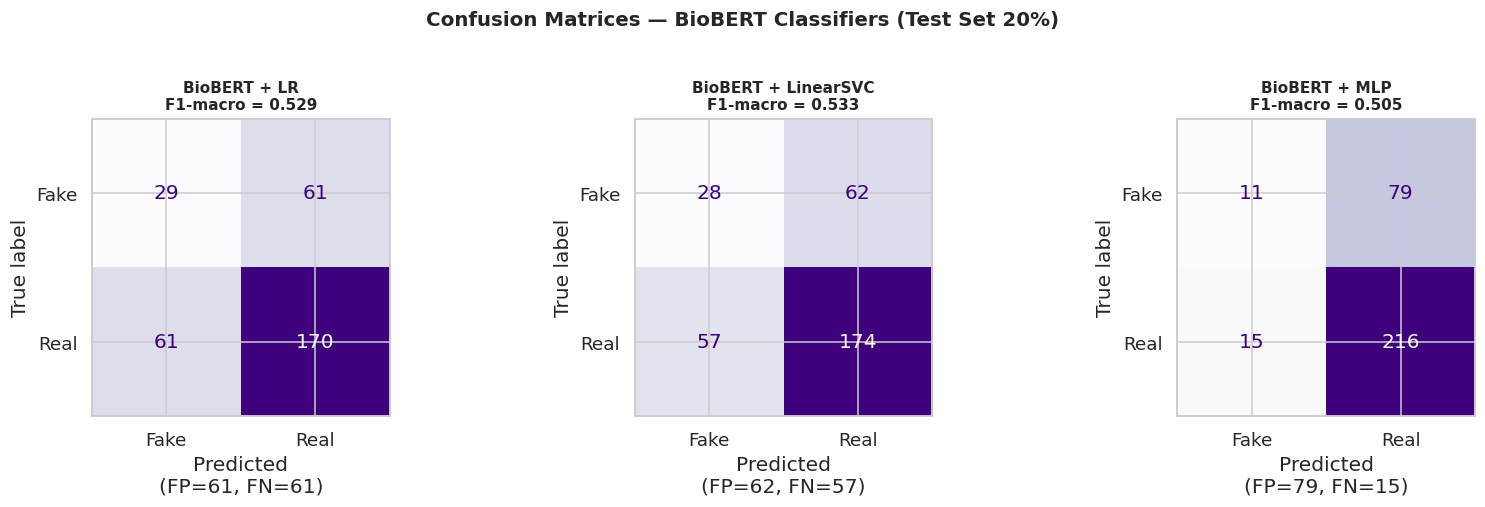

In [12]:
n_models = len(biobert_models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, test_results_bb.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Fake', 'Real'])
    disp.plot(ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(f'{name}\nF1-macro = {res["f1_macro"]:.3f}',
                 fontsize=10, fontweight='bold')
    fn = cm[1][0]
    fp = cm[0][1]
    ax.set_xlabel(f'Predicted\n(FP={fp}, FN={fn})')

plt.suptitle('Confusion Matrices — BioBERT Classifiers (Test Set 20%)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_biobert_confusion_matrices.png', bbox_inches='tight', dpi=130)
plt.show()



In [18]:

print('=' * 100)

# Header
header = f'{"Modèle":<30} {"Acc":>7} {"Prec":>7} {"Recall":>7} {"F1-mac":>7} {"F1-Fake":>8} {"F1-Real":>8} {"CV F1±σ":>13}'
print(header)
print('-' * 80)

for name, res in test_results_bb.items():
    # Use cross-validation results (cv_results_bb) to compute CV F1 mean/std
    cv = cv_results_bb.get(name)
    if cv is not None and 'test_f1_macro' in cv:
        cv_f1_mean = cv['test_f1_macro'].mean()
        cv_f1_std  = cv['test_f1_macro'].std()
    else:
        cv_f1_mean = float('nan')
        cv_f1_std = float('nan')

    row = (
        f'{name:<30} '
        f'{res["accuracy"]:>7.3f} '
        f'{res["prec_macro"]:>7.3f} '
        f'{res["rec_macro"]:>7.3f} '
        f'{res["f1_macro"]:>7.3f} '
        f'{res["f1_fake"]:>8.3f} '
        f'{res["f1_real"]:>8.3f} '
        f'{cv_f1_mean:>6.3f}±{cv_f1_std:.3f}'
    )
    print(row)

print('=' * 100)
print()

Modèle                             Acc    Prec  Recall  F1-mac  F1-Fake  F1-Real       CV F1±σ
--------------------------------------------------------------------------------
BioBERT + LR                     0.620   0.529   0.529   0.529    0.322    0.736  0.508±0.019
BioBERT + LinearSVC              0.629   0.533   0.532   0.533    0.320    0.745  0.500±0.023
BioBERT + MLP                    0.707   0.578   0.529   0.505    0.190    0.821  0.492±0.024

